# Okruženje galaksija i AGN aktivnost — TNG100-1

Pitanje: kako se AGN aktivnost razlikuje sa masom matičnog halo-a, uz kontrolu
zvezdane mase i razdvajanje centralnih i satelitskih galaksija?
Analiza koristi snapshot 99 (z ≈ 0), bez analize prečki.




In [3]:
"""Reproduktivna analiza okruženja i AGN aktivnosti u TNG100-1."""
import hashlib
import json
import platform
from importlib.metadata import version
from pathlib import Path

import h5py as hp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.stats import pearsonr, spearmanr


In [4]:
GROUPCAT_DIR = Path("data/group99")
OUTPUT_DIR = Path("outputs")
SNAP = 99
RANDOM_SEED = 42
N_BOOTSTRAP = 1000


In [6]:
# Čitamo samo delove izabranog snapshota, ne proizvoljne HDF5 fajlove.
files = list(GROUPCAT_DIR.glob(f"groupcat-{SNAP}.*.hdf5"))
files += list(GROUPCAT_DIR.glob(f"fof_subhalo_tab_{SNAP:03d}.*.hdf5"))
if not files:
    raise FileNotFoundError(
        f"Nema delova kataloga u {GROUPCAT_DIR}. Potrebni su svi delovi; vidi README.md."
    )
try:
    files.sort(key=lambda name: int(name.name.split(".")[-2]))
except ValueError as exc:
    raise ValueError("Broj dela HDF5 kataloga mora biti ceo broj u nazivu fajla.") from exc

count_keys = ("NumFiles", "Ngroups_Total", "Nsubgroups_Total",
              "Ngroups_ThisFile", "Nsubgroups_ThisFile")
physical_keys = ("HubbleParam", "Redshift", "Time", "BoxSize")
header = None
input_parts = []
for filename in files:
    with hp.File(filename, "r") as data:
        if "Header" not in data:
            raise KeyError(f"Nedostaje Header: {filename}")
        attrs = dict(data["Header"].attrs)
        for key in count_keys + physical_keys:
            if key not in attrs:
                raise KeyError(f"Nedostaje Header/{key}: {filename}")
            value = np.asarray(attrs[key])
            if value.ndim != 0 or value.dtype.kind not in "iuf":
                raise ValueError(f"Header/{key} mora biti numerički skalar: {filename}")
            if not np.isfinite(value):
                raise ValueError(f"Nevažeći Header/{key}: {filename}")
        for key in count_keys:
            if attrs[key] < 0 or attrs[key] != int(attrs[key]):
                raise ValueError(f"Header/{key} mora biti nenegativan ceo broj: {filename}")
        if header is None:
            header = attrs
        for key in count_keys[:3]:
            if attrs[key] != header[key]:
                raise ValueError(f"Neusklađen Header/{key}: {filename}")
        for key in physical_keys:
            if not np.isclose(attrs[key], header[key], rtol=1e-10, atol=1e-12):
                raise ValueError(f"Pomešani katalozi, Header/{key}: {filename}")
        input_parts.append({
            "name": filename.name, "size_bytes": filename.stat().st_size,
            "groups": int(attrs["Ngroups_ThisFile"]),
            "subhalos": int(attrs["Nsubgroups_ThisFile"]),
        })

expected_files = int(header["NumFiles"])
expected_groups = int(header["Ngroups_Total"])
expected_subhalos = int(header["Nsubgroups_Total"])
chunk_ids = [int(name.name.split(".")[-2]) for name in files]
if chunk_ids != list(range(expected_files)):
    raise ValueError("Nedostaju delovi kataloga ili postoje duplikati brojeva delova.")
if expected_groups == 0 or expected_subhalos == 0:
    raise ValueError("Katalog nema halo grupe ili subhaloe za analizu.")
if sum(part["groups"] for part in input_parts) != expected_groups:
    raise ValueError("Zbir Ngroups_ThisFile ne odgovara Ngroups_Total.")
if sum(part["subhalos"] for part in input_parts) != expected_subhalos:
    raise ValueError("Zbir Nsubgroups_ThisFile ne odgovara Nsubgroups_Total.")
if SNAP != 99 or not np.isclose(header["Redshift"], 0., atol=1e-8):
    raise ValueError("Ovaj notebook je namenjen snapshot-u 99, z približno 0.")
if not np.isclose(header["Time"], 1 / (1 + header["Redshift"]), atol=1e-8):
    raise ValueError("Header/Time nije saglasan sa Redshift.")
if (not np.isclose(header["HubbleParam"], 0.6774)
        or not np.isclose(header["BoxSize"], 75000.)):
    raise ValueError("h ili BoxSize ne odgovaraju očekivanom TNG100 katalogu.")
print("Broj delova:", len(files))
print("Očekivani broj grupa/subhaloa:", expected_groups, expected_subhalos)


Broj delova: 448
Očekivani broj grupa/subhaloa: 6291349 4371211


In [8]:
FIELD_GROUP_LIMIT = 5e12       # Msun; operativna donja granica grupa
GROUP_CLUSTER_LIMIT = 8e13     # Msun; motivisano Paul et al. (2017)
MSTAR_MIN = 1e9                # Msun; proveriti osetljivost na ovaj izbor
LAMBDA_EDD_LIMIT = 1e-3        # operativna definicija AGN kandidata


## Učitavanje i jedinice

`Group` sadrži halo grupe, `Subhalo` njihove subhaloe. Brojevi redova su globalni
indeksi samo kada su svi delovi spojeni numeričkim redosledom.
Proveravamo dimenzije, ukupan broj objekata i konzistentnost veza.

Mase su u `1e10 Msun/h`; akrecija je u `(1e10 Msun/h)/(0.978 Gyr/h)`.
`SubhaloMassType[:, 4]` daje ukupnu vezanu zvezdanu masu. BH masa i akrecija
su sume po subhalou. SFR je već u `Msun/yr`, položaji u `ckpc/h`.
Izvor: [TNG specifikacije](https://www.tng-project.org/data/docs/specifications/).


In [10]:
def ucitaj_polje(fajlovi, grupa, polje):
    """Spoji polje uz provere dimenzija, tipa i broja redova u svakom delu."""
    keys = {"Group": ("Ngroups_ThisFile", "Ngroups_Total"),
            "Subhalo": ("Nsubgroups_ThisFile", "Nsubgroups_Total")}
    count_key, total_key = keys[grupa]
    tail_shape = {"SubhaloMassType": (6,), "SubhaloPos": (3,)}.get(polje, ())
    #integer_fields = {"SubhaloGrNr", "GroupFirstSub", "GroupNsubs", "SubhaloFlag"} *******
    integer_fields = {"SubhaloGrNr", "GroupFirstSub", "GroupNsubs"}
    chunks = []
    expected_total = None
    for part in fajlovi:
        with hp.File(part, "r") as handle:
            count = int(handle["Header"].attrs[count_key])
            total = int(handle["Header"].attrs[total_key])
            if expected_total is None:
                expected_total = total
            elif total != expected_total:
                raise ValueError(f"Neusklađen ukupan broj: {part}")
            if grupa not in handle or polje not in handle[grupa]:
                if count == 0:
                    continue
                raise KeyError(f"Nedostaje {grupa}/{polje} u {part}")
            dataset = handle[grupa][polje]
            expected_shape = (count,) + tail_shape
            if not isinstance(dataset, hp.Dataset) or dataset.shape != expected_shape:
                raise ValueError(f"Pogrešan oblik {grupa}/{polje} u {part}; "
                                 f"očekivano {expected_shape}")
            #if dataset.dtype.kind not in "iuf": **********
            if dataset.dtype.kind not in "iufb":
                raise ValueError(f"Polje {grupa}/{polje} nije numeričko: {part}")
            if polje in integer_fields and dataset.dtype.kind not in "iu":
                raise ValueError(f"Polje {grupa}/{polje} mora biti celobrojno: {part}")
            values = dataset[:]
            # Dokumentacija dozvoljava unsigned zapis sentinela -1 za GroupFirstSub.
            if polje == "GroupFirstSub" and values.dtype.kind == "u":
                sentinel = values == np.iinfo(values.dtype).max
                if np.any(values[~sentinel] > np.iinfo(np.int64).max):
                    raise ValueError("GroupFirstSub indeks izvan int64 opsega.")
                values = values.astype(np.int64)
                values[sentinel] = -1
            elif polje in integer_fields:
                if values.dtype.kind == "u" and np.any(values > np.iinfo(np.int64).max):
                    raise ValueError(f"{polje} indeks izvan int64 opsega.")
                values = values.astype(np.int64)
            chunks.append(values)
    if not chunks:
        raise ValueError(f"Nisam našao polje {grupa}/{polje}")
    result = np.concatenate(chunks, axis=0)
    if len(result) != expected_total:
        raise ValueError(f"Nepotpun katalog za {grupa}/{polje}")
    return result


def pozitivan_log(values):
    """Log10 samo za pozitivne konačne vrednosti, ostalo je NaN."""
    values = np.asarray(values, dtype=np.float64)
    valid = np.isfinite(values) & (values > 0)
    return np.log10(values, where=valid, out=np.full(values.shape, np.nan))


In [11]:
h = float(header["HubbleParam"])
redshift = float(header["Redshift"])
scale_factor = float(header["Time"])
print("h, z, a =", h, redshift, scale_factor)


h, z, a = 0.6774 2.220446049250313e-16 0.9999999999999998


In [12]:
# Masa u sferi srednje gustine 200 * kritična gustina.
Group_M_Crit200 = ucitaj_polje(files, "Group", "Group_M_Crit200")
GroupFirstSub = ucitaj_polje(files, "Group", "GroupFirstSub")
GroupNsubs = ucitaj_polje(files, "Group", "GroupNsubs")


In [13]:
SubhaloFlag = ucitaj_polje(files, "Subhalo", "SubhaloFlag")
SubhaloGrNr = ucitaj_polje(files, "Subhalo", "SubhaloGrNr")


if not np.isin(SubhaloFlag, [0, 1]).all():
    raise ValueError("SubhaloFlag mora sadržati samo 0 ili 1.")


In [14]:
SubhaloMassType = ucitaj_polje(files, "Subhalo", "SubhaloMassType")
SubhaloBHMass = ucitaj_polje(files, "Subhalo", "SubhaloBHMass")

In [19]:
SubhaloBHMdot = ucitaj_polje(files, "Subhalo", "SubhaloBHMdot")
SubhaloSFR = ucitaj_polje(files, "Subhalo", "SubhaloSFR")

In [20]:
SubhaloPos = ucitaj_polje(files, "Subhalo", "SubhaloPos")

In [21]:
# Float64 pre množenja. h se poništava samo u konverziji akrecione stope.
M200c_all = Group_M_Crit200.astype(np.float64) * 1e10 / h
Mstar = SubhaloMassType[:, 4].astype(np.float64) * 1e10 / h
MBH = SubhaloBHMass.astype(np.float64) * 1e10 / h
Mdot_BH = SubhaloBHMdot.astype(np.float64) * 1e10 / 0.978e9


In [22]:
parent_group_id = SubhaloGrNr
SubfindID = np.arange(len(SubhaloGrNr), dtype=np.int64)
valid_parent = (parent_group_id >= 0) & (parent_group_id < len(M200c_all))
if not valid_parent.all():
    raise ValueError("Nevažeći SubhaloGrNr u kompletnom katalogu.")
if np.any(GroupNsubs < 0):
    raise ValueError("GroupNsubs mora biti nenegativan.")
counts = np.bincount(parent_group_id, minlength=len(GroupNsubs))
if not np.array_equal(counts, GroupNsubs):
    raise ValueError("SubhaloGrNr i GroupNsubs se ne slažu.")
if np.any(np.diff(parent_group_id) < 0):
    raise ValueError("SubhaloGrNr nije u globalnom redosledu halo grupa.")

occupied_groups = np.flatnonzero(GroupNsubs > 0)
central_ids = GroupFirstSub[occupied_groups]
if np.any((central_ids < 0) | (central_ids >= len(SubfindID))):
    raise ValueError("Nevažeći GroupFirstSub za nepraznu grupu.")
if np.any(GroupFirstSub[GroupNsubs == 0] != -1):
    raise ValueError("Prazna grupa mora imati GroupFirstSub = -1.")
expected_first = np.cumsum(GroupNsubs, dtype=np.int64) - GroupNsubs
if not np.array_equal(central_ids, expected_first[occupied_groups]):
    raise ValueError("GroupFirstSub nije prvi globalni subhalo svoje grupe.")
if not np.array_equal(parent_group_id[central_ids], occupied_groups):
    raise ValueError("GroupFirstSub i SubhaloGrNr se ne slažu.")

M200c_parent = M200c_all[parent_group_id]
is_central = SubfindID == GroupFirstSub[parent_group_id]
is_satellite = ~is_central
if int(is_central.sum()) != len(occupied_groups):
    raise ValueError("Svaka neprazna grupa mora imati tačno jednu centralnu galaksiju.")


In [23]:
MSUN_G = 1.98847e33
YEAR_S = 365.25 * 24 * 3600
C_LIGHT = 2.99792458e10
ETA = 0.1  # Zadržana postprocesna pretpostavka; TNG model koristi 0.2.
if not (0 < ETA <= 1 and LAMBDA_EDD_LIMIT > 0 and MSTAR_MIN > 0
        and 0 < FIELD_GROUP_LIMIT < GROUP_CLUSTER_LIMIT):
    raise ValueError("Nevažeći pragovi ili radijativna efikasnost.")

# Ako nevažeći ekstrem izazove overflow, vrednost ostaje nepoznata (ne AGN).
with np.errstate(over="ignore", invalid="ignore", divide="ignore"):
    Mdot_g_s = Mdot_BH * MSUN_G / YEAR_S
    L_bol = ETA * Mdot_g_s * C_LIGHT**2
    L_edd = 1.26e38 * MBH
    lambda_edd = np.full_like(MBH, np.nan, dtype=float)
    mask_bh = (np.isfinite(MBH) & (MBH > 0)
               & np.isfinite(Mdot_BH) & (Mdot_BH >= 0)
               & np.isfinite(L_bol) & np.isfinite(L_edd))
    lambda_edd[mask_bh] = L_bol[mask_bh] / L_edd[mask_bh]
lambda_edd[~np.isfinite(lambda_edd)] = np.nan
# MBH > 0 i Mdot_BH = 0 daju lambda_edd = 0: validna neaktivnost.


## Definicije uzorka i aktivnosti

$L_{bol}=\eta\dot M c^2$, $L_{Edd}=1.26\times10^{38}(M_{BH}/M_\odot)$ erg/s,
$\lambda=L_{bol}/L_{Edd}$. `ETA=0.1` je eksplicitna postprocesna pretpostavka,
ne merena efikasnost niti automatski stvarna luminoznost pri svakoj akreciji.
TNG model koristi 0.2; tabelom osetljivosti proveravamo oba izbora.

Osnovni uzorak: SubhaloFlag=1, konačna Mstar ≥ 1e9 Msun, konačna M200c > 0.
Rezovi po BH aktivnosti ne ulaze u izbor osnovnog uzorka. Nulta akrecija ostaje
u imeniocu frakcije; nepoznat status se broji odvojeno.
`field` je ovde operativna masena kategorija, ne potvrda prostorne izolovanosti.
Granica group/cluster-like motivisana je radom
[Paul et al. (2017)](https://arxiv.org/pdf/1706.01916).


In [25]:
okruzenje = np.full(len(M200c_parent), "unknown", dtype=object)
valid_halo_mass = np.isfinite(M200c_parent) & (M200c_parent > 0)
okruzenje[valid_halo_mass & (M200c_parent < FIELD_GROUP_LIMIT)] = "field"
okruzenje[valid_halo_mass & (M200c_parent >= FIELD_GROUP_LIMIT)
         & (M200c_parent < GROUP_CLUSTER_LIMIT)] = "group"
okruzenje[valid_halo_mass & (M200c_parent >= GROUP_CLUSTER_LIMIT)] = "cluster-like"


In [26]:
catalog = pd.DataFrame({
    "SubfindID": SubfindID, "parent_group_id": parent_group_id,
    "SubhaloFlag": SubhaloFlag, "is_central": is_central,
    "is_satellite": is_satellite, "Mstar": Mstar, "M200c_parent": M200c_parent,
    "MBH": MBH, "Mdot_BH": Mdot_BH, "lambda_edd": lambda_edd,
    "SFR": SubhaloSFR, "environment": okruzenje,
    "x": SubhaloPos[:, 0], "y": SubhaloPos[:, 1], "z": SubhaloPos[:, 2],
})
for column, log_column in (("Mstar", "logMstar"), ("M200c_parent", "logM200c_parent"),
                           ("MBH", "logMBH"), ("Mdot_BH", "logMdot_BH"),
                           ("lambda_edd", "log_lambda_edd")):
    catalog[log_column] = pozitivan_log(catalog[column])

catalog["is_agn"] = pd.Series(pd.NA, index=catalog.index, dtype="boolean")
known_bh = np.isfinite(lambda_edd)
catalog.loc[known_bh, "is_agn"] = lambda_edd[known_bh] >= LAMBDA_EDD_LIMIT
no_bh = np.isfinite(MBH) & (MBH == 0) & np.isfinite(Mdot_BH) & (Mdot_BH == 0)
catalog.loc[no_bh, "is_agn"] = False

# Kumulativni izveštaj o selekciji, uključujući nepoznato okruženje.
base_mask = np.ones(len(catalog), dtype=bool)
selection_rows = []
selection_steps = [
    ("svi_subhaloi", np.ones(len(catalog), dtype=bool)),
    ("SubhaloFlag_1", SubhaloFlag == 1),
    ("konacna_Mstar", np.isfinite(Mstar)),
    ("Mstar_min", Mstar >= MSTAR_MIN),
    ("validna_M200c", valid_halo_mass),
]
for step, condition in selection_steps:
    base_mask &= condition
    row = {"korak": step, "ukupno": int(base_mask.sum())}
    for env in ("field", "group", "cluster-like", "unknown"):
        row[env] = int(np.sum(base_mask & (okruzenje == env)))
    selection_rows.append(row)
selection = pd.DataFrame(selection_rows)
clean = catalog.loc[base_mask].copy()
print(selection.to_string(index=False))
print("Nepoznat AGN status u osnovnom uzorku:", clean["is_agn"].isna().sum())
# x, y, z su ckpc/h; fizički kpc = koordinata * a / h.


        korak  ukupno   field  group  cluster-like  unknown
 svi_subhaloi 4371211 3991623 237202        135380     7006
SubhaloFlag_1 4361030 3986161 233394        134469     7006
konacna_Mstar 4361030 3986161 233394        134469     7006
    Mstar_min   21052   14397   4256          2399        0
validna_M200c   21052   14397   4256          2399        0
Nepoznat AGN status u osnovnom uzorku: 0


In [27]:
def pregled_uzorka(frame, by):
    """Frakcije sa eksplicitnim imeniocem i granicama za nepoznate statuse."""
    result = frame.groupby(by, observed=True).agg(
        broj_galaksija=("SubfindID", "count"),
        broj_haloa=("parent_group_id", "nunique"),
        broj_sa_AGN_statusom=("is_agn", "count"),
        broj_AGN=("is_agn", "sum"),
        AGN_frakcija=("is_agn", "mean"),
        medijana_logMstar=("logMstar", "median"),
        medijana_logM200c=("logM200c_parent", "median"),
        medijana_log_lambda_edd=("log_lambda_edd", "median"),
        medijana_logMdot_BH=("logMdot_BH", "median"),
    )
    result["broj_nepoznatih"] = result["broj_galaksija"] - result["broj_sa_AGN_statusom"]
    result["AGN_frakcija_min"] = result["broj_AGN"] / result["broj_galaksija"]
    result["AGN_frakcija_max"] = (
        (result["broj_AGN"] + result["broj_nepoznatih"]) / result["broj_galaksija"]
    )
    return result


summary = pregled_uzorka(clean, "environment")
summary_central = pregled_uzorka(clean, ["environment", "is_central"])
summary_bh = pregled_uzorka(clean[np.isfinite(clean["MBH"]) & (clean["MBH"] > 0)],
                          "environment")
print(summary)
print(summary_central)
print("Frakcije su među poznatim statusima; min/max opisuju nepoznate, ne statistički CI.")
print("Medijane log(lambda) i log(Mdot) uključuju samo pozitivne konačne vrednosti.")


              broj_galaksija  broj_haloa  broj_sa_AGN_statusom  broj_AGN  \
environment                                                                
cluster-like            2399          20                  2399       278   
field                  14397       11865                 14397      9546   
group                   4256         363                  4256      1193   

              AGN_frakcija  medijana_logMstar  medijana_logM200c  \
environment                                                        
cluster-like      0.115882           9.694352          14.318013   
field             0.663055           9.580009          11.522352   
group              0.28031           9.739391          13.251766   

              medijana_log_lambda_edd  medijana_logMdot_BH  broj_nepoznatih  \
environment                                                                   
cluster-like                -7.189679            -6.597610                0   
field                       -2.482191    

In [29]:
def korelacija(frame, x_col, y_col):
    """Deskriptivne korelacije konačnih parova; naivni p nije halo-aware test."""
    pairs = frame[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna()
    result = {"x": x_col, "y": y_col, "n": len(pairs),
              "pearson_r": np.nan, "pearson_p": np.nan,
              "spearman_rho": np.nan, "spearman_p": np.nan}
    if len(pairs) < 3 or pairs[x_col].nunique() < 2 or pairs[y_col].nunique() < 2:
        print("Korelacija nije definisana: premalo parova ili konstantan niz.")
        return result
    result["pearson_r"], result["pearson_p"] = pearsonr(pairs[x_col], pairs[y_col])
    result["spearman_rho"], result["spearman_p"] = spearmanr(pairs[x_col], pairs[y_col])
    print(result)
    if result["pearson_p"] == 0 or result["spearman_p"] == 0:
        print("p=0 je numerički ispis, ne dokaz apsolutne sigurnosti.")
    return result


In [30]:
correlations = pd.DataFrame([
    korelacija(clean, "logM200c_parent", "log_lambda_edd"),
    korelacija(clean, "logM200c_parent", "logMdot_BH"),
    korelacija(clean, "logMstar", "log_lambda_edd"),
])


{'x': 'logM200c_parent', 'y': 'log_lambda_edd', 'n': 18981, 'pearson_r': np.float64(-0.5415549054954958), 'pearson_p': np.float64(0.0), 'spearman_rho': np.float64(-0.40622369944075065), 'spearman_p': np.float64(0.0)}
p=0 je numerički ispis, ne dokaz apsolutne sigurnosti.
{'x': 'logM200c_parent', 'y': 'logMdot_BH', 'n': 18981, 'pearson_r': np.float64(-0.4043888214043649), 'pearson_p': np.float64(0.0), 'spearman_rho': np.float64(-0.1596789686242551), 'spearman_p': np.float64(1.3034457852628027e-108)}
p=0 je numerički ispis, ne dokaz apsolutne sigurnosti.
{'x': 'logMstar', 'y': 'log_lambda_edd', 'n': 18981, 'pearson_r': np.float64(-0.23998197259570586), 'pearson_p': np.float64(8.428504419540254e-247), 'spearman_rho': np.float64(-0.28270831470644975), 'spearman_p': np.float64(0.0)}
p=0 je numerički ispis, ne dokaz apsolutne sigurnosti.


## Grafikoni i statistička interpretacija

Korelacije opisuju povezanost, ne uzročnost. Njihove uobičajene p-vrednosti ne
uvažavaju zajednički halo, razlike u Mstar i udelu satelita.
Logaritamski grafikoni prikazuju samo pozitivne konačne parove, uključujući
objekte ispod AGN praga. Nulte akrecije su i dalje uključene u AGN frakcije.

Za poređenje sirovog i odabranog uzorka koristimo iste ivice binova.
Prazan skup pozitivnih parova daje objašnjenje u grafikonu, ne grešku.


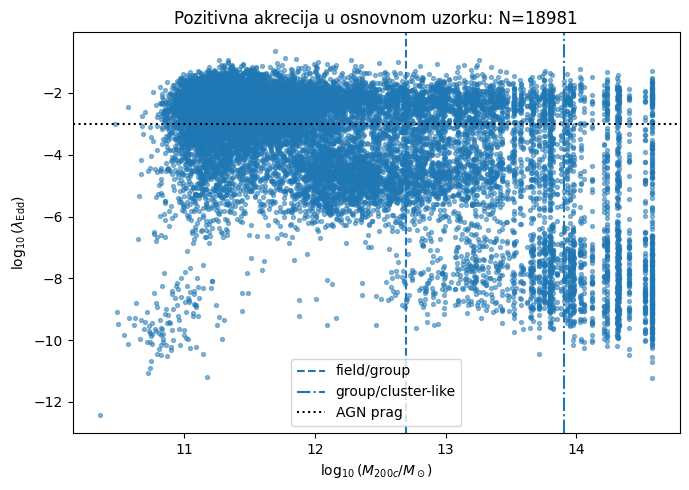

In [32]:
plot_data = clean[["logM200c_parent", "log_lambda_edd"]].dropna()
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(plot_data["logM200c_parent"], plot_data["log_lambda_edd"], s=8, alpha=0.5)
ax.axvline(np.log10(FIELD_GROUP_LIMIT), linestyle="--", label="field/group")
ax.axvline(np.log10(GROUP_CLUSTER_LIMIT), linestyle="-.", label="group/cluster-like")
ax.axhline(np.log10(LAMBDA_EDD_LIMIT), color="black", linestyle=":", label="AGN prag")
ax.set_xlabel(r"$\log_{10}(M_{200c}/M_\odot)$")
ax.set_ylabel(r"$\log_{10}(\lambda_{\rm Edd})$")
ax.set_title(f"Pozitivna akrecija u osnovnom uzorku: N={len(plot_data)}")
if plot_data.empty:
    ax.text(0.5, 0.5, "Nema pozitivnih konačnih parova", transform=ax.transAxes, ha="center")
ax.legend()
fig.tight_layout()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(OUTPUT_DIR / "lambda_edd_vs_m200c.png", dpi=200)
plt.show()
plt.close(fig)


In [33]:
def histogram_bh(frame, bins, title, output_name, logarithmic=False):
    """2D histogram sa istim granicama i bez LogNorm greške za prazan uzorak."""
    pairs = frame[["logMBH", "log_lambda_edd"]].dropna()
    figure, axis = plt.subplots(figsize=(7, 5))
    if pairs.empty:
        axis.text(0.5, 0.5, "Nema pozitivnih konačnih parova",
                  transform=axis.transAxes, ha="center")
    else:
        norm = LogNorm(vmin=1) if logarithmic else None
        histogram = axis.hist2d(pairs["logMBH"], pairs["log_lambda_edd"],
                                bins=bins, norm=norm, cmin=1 if logarithmic else None)
        figure.colorbar(histogram[3], ax=axis, label="Broj subhaloa")
    axis.set_xlabel(r"$\log_{10}(M_{\rm BH}/M_\odot)$")
    axis.set_ylabel(r"$\log_{10}(\lambda_{\rm Edd})$")
    axis.set_title(f"{title}, N={len(pairs)}")
    figure.tight_layout()
    figure.savefig(OUTPUT_DIR / output_name, dpi=200)
    plt.show()
    plt.close(figure)


In [34]:
raw_pairs = catalog[["logMBH", "log_lambda_edd"]].dropna()
if raw_pairs.empty:
    bh_bins = [np.linspace(0., 1., 51), np.linspace(-8., 0., 51)]
else:
    bh_bins = [np.histogram_bin_edges(raw_pairs[column], bins=50)
               for column in ("logMBH", "log_lambda_edd")]


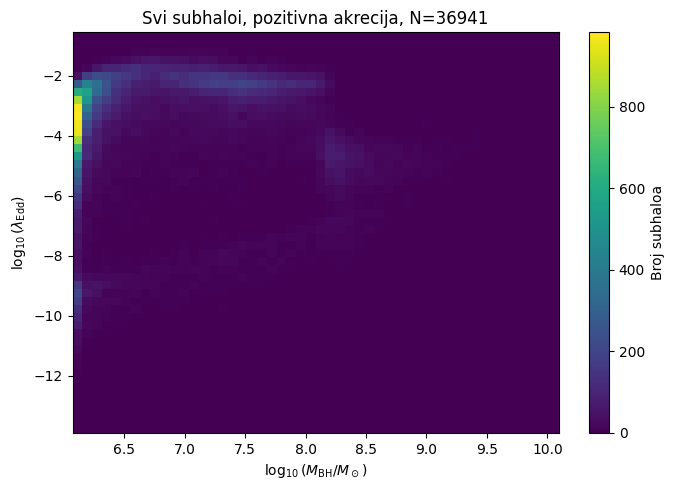

In [35]:
histogram_bh(catalog, bh_bins, "Svi subhaloi, pozitivna akrecija", "bh_raw.png")


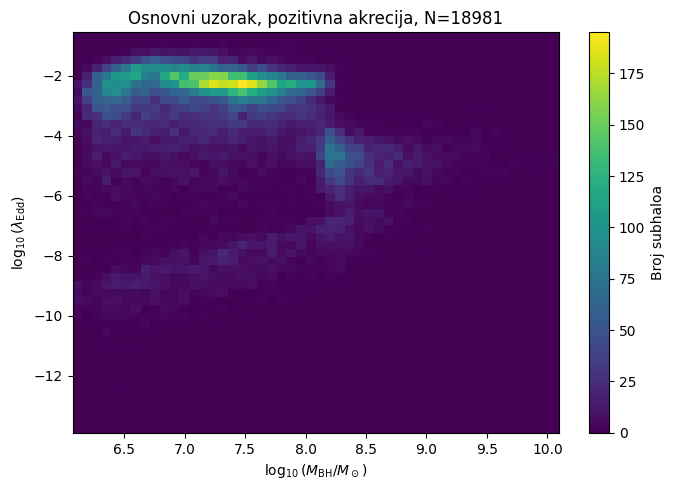

In [36]:
histogram_bh(clean, bh_bins, "Osnovni uzorak, pozitivna akrecija", "bh_clean.png")


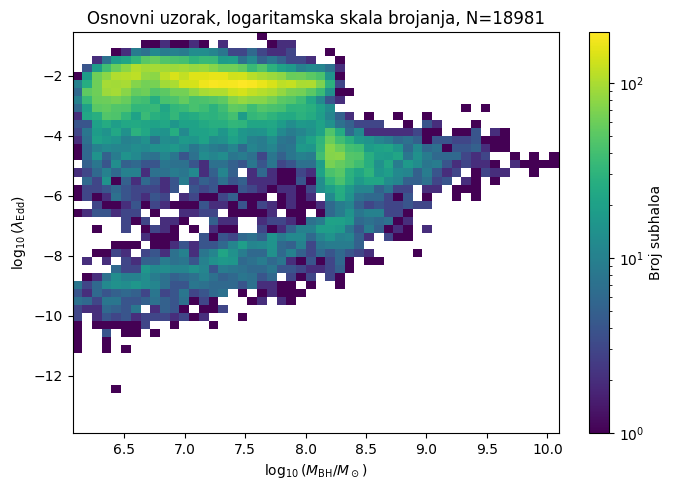

In [37]:
histogram_bh(clean, bh_bins, "Osnovni uzorak, logaritamska skala brojanja",
             "bh_clean_lognorm.png", logarithmic=True)


In [39]:
def halo_interval(frame, rng, n_resamples=1000):
    """Percentilni 95% CI za odnos brojeva, resampliranjem celih halo grupa."""
    known = frame.dropna(subset=["is_agn"])
    groups = known.groupby("parent_group_id")["is_agn"].agg(["sum", "count"])
    if len(groups) < 2:
        return np.nan, np.nan, len(groups)
    counts_array = groups[["sum", "count"]].to_numpy(dtype=float)
    fractions = np.empty(n_resamples)
    for index in range(n_resamples):
        draw = rng.integers(0, len(groups), size=len(groups))
        numerator, denominator = counts_array[draw].sum(axis=0)
        fractions[index] = numerator / denominator
    lo, hi = np.quantile(fractions, [0.025, 0.975])
    return lo, hi, len(groups)


rng = np.random.default_rng(RANDOM_SEED)
mass_rows = []
if not clean.empty:
    mass_edges = np.arange(np.floor(clean["logMstar"].min() * 2) / 2,
                           np.ceil(clean["logMstar"].max() * 2) / 2 + 1., .5)
    mass_sample = clean.assign(mass_bin=pd.cut(clean["logMstar"], mass_edges, right=False))
    for (env, central, mass_bin), subset in mass_sample.groupby(
            ["environment", "is_central", "mass_bin"], observed=True):
        known_count = int(subset["is_agn"].count())
        agn_count = int(subset["is_agn"].sum())
        lo, hi, halo_count = halo_interval(subset, rng, N_BOOTSTRAP)
        mass_rows.append({
            "environment": env, "is_central": bool(central),
            "logMstar_mid": mass_bin.mid, "N": len(subset),
            "N_known": known_count, "N_AGN": agn_count, "N_halo_known": halo_count,
            "AGN_fraction": agn_count / known_count if known_count else np.nan,
            "ci_low": lo, "ci_high": hi,
        })
mass_fractions = pd.DataFrame(mass_rows, columns=[
    "environment", "is_central", "logMstar_mid", "N", "N_known", "N_AGN",
    "N_halo_known", "AGN_fraction", "ci_low", "ci_high",
])
print(mass_fractions)
print("Bootstrap CI je eksplorativan pri malom broju halo-a; ne meri kosmičku varijansu.")


     environment  is_central  logMstar_mid     N  N_known  N_AGN  \
0   cluster-like       False          9.25   932      932     93   
1   cluster-like       False          9.75   616      616     96   
2   cluster-like       False         10.25   448      448     70   
3   cluster-like       False         10.75   293      293     19   
4   cluster-like       False         11.25    67       67      0   
5   cluster-like       False         11.75    23       23      0   
6   cluster-like        True         11.75     7        7      0   
7   cluster-like        True         12.25    12       12      0   
8   cluster-like        True         12.75     1        1      0   
9          field       False          9.25  1399     1399    819   
10         field       False          9.75   713      713    545   
11         field       False         10.25   327      327    217   
12         field       False         10.75   111      111     33   
13         field       False         11.25     3

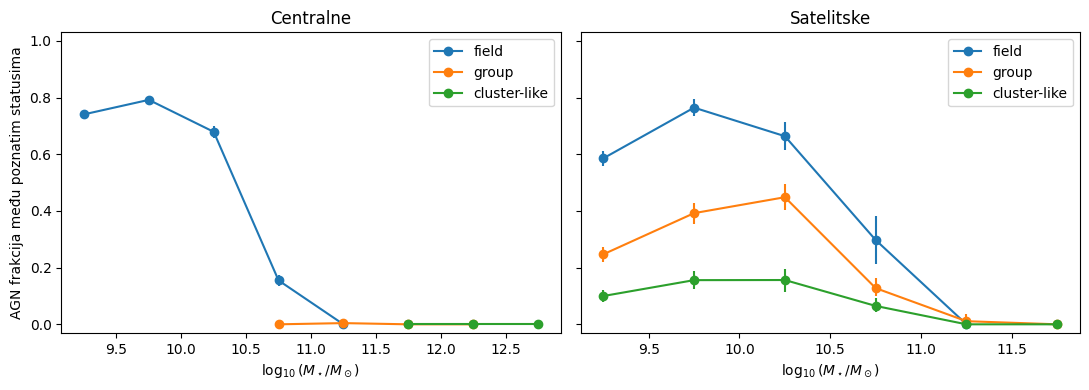

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, central, label in zip(axes, [True, False], ["Centralne", "Satelitske"]):
    for env in ("field", "group", "cluster-like"):
        rows = mass_fractions[(mass_fractions["environment"] == env)
                              & (mass_fractions["is_central"] == central)]
        if not rows.empty:
            line, = ax.plot(rows["logMstar_mid"], rows["AGN_fraction"], "o-", label=env)
            # CI ne mora biti simetričan niti centriran na tačkastu procenu.
            ax.vlines(rows["logMstar_mid"], rows["ci_low"], rows["ci_high"],
                      color=line.get_color())
    ax.set_title(label)
    ax.set_xlabel(r"$\log_{10}(M_\star/M_\odot)$")
    ax.set_ylim(-0.03, 1.03)
    if ax.lines:
        ax.legend()
    else:
        ax.text(.5, .5, "Nema galaksija u uzorku", transform=ax.transAxes, ha="center")
axes[0].set_ylabel("AGN frakcija među poznatim statusima")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "agn_fraction_vs_mstar.png", dpi=200)
plt.show()
plt.close(fig)


In [43]:
# Osetljivost na eksplicitne postprocesne pretpostavke, bez promene clean uzorka.
sensitivity_rows = []
for eta_test in (0.1, 0.2):
    for mass_cut in (1e9, 10**9.5, 1e10):
        for threshold in (1e-4, 1e-3, 1e-2):
            for env, subset in clean[clean["Mstar"] >= mass_cut].groupby("environment"):
                known = subset["is_agn"].notna()
                scaled_lambda = subset["lambda_edd"] * eta_test / ETA
                n_known = int(known.sum())
                n_agn = int((known & (scaled_lambda >= threshold)).sum())
                sensitivity_rows.append({
                    "eta": eta_test, "Mstar_min": mass_cut, "lambda_limit": threshold,
                    "environment": env, "N": len(subset), "N_known": n_known,
                    "N_AGN": n_agn, "AGN_fraction": n_agn / n_known if n_known else np.nan,
                })
sensitivity = pd.DataFrame(sensitivity_rows, columns=[
    "eta", "Mstar_min", "lambda_limit", "environment", "N", "N_known", "N_AGN",
    "AGN_fraction",
])


In [44]:
#print(sensitivity)

## Kako tumačiti rezultate

`summary` daje osnovnu demografiju; `summary_central` razdvaja tipove galaksija,
`summary_bh` uslovljava uzorak prisustvom rezolvirane BH. Imenilac svake frakcije
je eksplicitno naveden. Granice min/max za nepoznate statuse nisu intervali
poverenja. `mass_fractions` poredi mase po binovima od 0.5 dex; to smanjuje,
ali ne uklanja potpuno, razlike masenih raspodela unutar binova.

Bootstrap bira cele halo-e sa ponavljanjem. Grupe sa mnogo satelita zadržavaju
svoje težine u frakciji galaksija. CI sa <2 halo-a nije definisan; čak i uz
nekoliko halo-a može biti nestabilan. Prostorne korelacije između halo-a,
rezolucija, BH seeding i konačna zapremina ostaju ograničenja.

Tabela `sensitivity` omogućava proveru da li znak i veličina razlike zavise od
AGN praga, ETA ili zvezdane mase. Ne bira se prag naknadno zato što daje
najmanju p-vrednost. Nema zaključka o uzročnosti samo na osnovu korelacije.


## Reprodukcija 

Izlazi sledeće ćelije pripadaju isključivo ovom izvršavanju. CSV osnovnog uzorka
zadržava i neaktivne galaksije; nije dovoljan za smanjenje masenog reza ispod
MSTAR_MIN. Izvoz sadrži kontrolnu sumu i opis metoda.



## Provera smislenosti

- Zbir brojeva po okruženjima mora odgovarati osnovnom uzorku.
- Broj AGN ≤ broj poznatih statusa ≤ broj galaksija; frakcije su između 0 i 1.
- Nulta akrecija nije nedostajući podatak. Prazan graf pozitivnih vrednosti
  može biti smislen i mora biti jasno označen.
- U punom katalogu svaka neprazna grupa ima jednu centralnu galaksiju;




In [48]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
catalog_path = OUTPUT_DIR / "catalog_base.csv.gz"
clean.to_csv(catalog_path, index=False, compression={"method": "gzip", "mtime": 0})
for name, table in (("summary", summary), ("summary_central", summary_central),
                    ("summary_bh", summary_bh)):
    table.to_csv(OUTPUT_DIR / f"{name}.csv")
for name, table in (("selection", selection), ("correlations", correlations),
                    ("mass_fractions", mass_fractions), ("sensitivity", sensitivity)):
    table.to_csv(OUTPUT_DIR / f"{name}.csv", index=False)
metadata = {
    "schema_version": 1, "analysis_revision": "2026-09-20",
    "simulation_expected": "TNG100-1", "snapshot": SNAP,
    "h": h, "redshift": redshift, "scale_factor": scale_factor,
    "eta": ETA, "mstar_min_msun": MSTAR_MIN, "lambda_edd_limit": LAMBDA_EDD_LIMIT,
    "field_group_limit_msun": FIELD_GROUP_LIMIT,
    "group_cluster_limit_msun": GROUP_CLUSTER_LIMIT,
    "seed": RANDOM_SEED, "bootstrap_resamples": N_BOOTSTRAP,
    "input_parts": input_parts, "input_content_hashes_computed": False,
    "input_kind": "synthetic_test" if header.get("SyntheticTest", 0) else "user_catalog",
    "ngroups_total": expected_groups, "nsubhalos_total": expected_subhalos,
    "base_sample_count": len(clean),
    "catalog_sha256": hashlib.sha256(catalog_path.read_bytes()).hexdigest(),
    "python": platform.python_version(),
    "packages": {name: version(name) for name in ("numpy", "pandas", "scipy", "h5py",
                                                  "matplotlib")},
    "units": {"Mstar": "Msun", "MBH": "Msun (sum in subhalo)",
              "M200c_parent": "Msun", "Mdot_BH": "Msun/yr",
              "SFR": "Msun/yr", "positions": "ckpc/h", "lambda_edd": "dimensionless"},
    "note": "Derived base sample; lower mass cuts require reprocessing original input.",
}
(OUTPUT_DIR / "catalog_metadata.json").write_text(
    json.dumps(metadata, indent=2, ensure_ascii=False), encoding="utf-8"
)
print("Izvezeni su katalog, metapodaci, tabele i grafikoni u outputs/.")


Izvezeni su katalog, metapodaci, tabele i grafikoni u outputs/.
